<div style="background-image: linear-gradient(to right, #2e5a88, #1e1e1e); color: white; padding: 12px 25px; border-radius: 10px; margin-top: 25px; margin-bottom: 15px;">
    <h1 style="color: white; margin: 0; font-size: 2.0em; font-family: 'Consolas', monospace;">
        H4 · Supply Quality &amp; Voltage Stability Diagnosis
    </h1>
    <p style="color: #d1d1d1; margin: 5px 0 0 0; font-size: 1.1em;">Residential Power Consumption Audit · Sceaux Dataset</p>
    <p style="color: #aaaaaa; margin: 4px 0 0 0; font-size: 0.95em;">Aitor — Industrial Electrical Engineer &amp; Data Engineer</p>
</div>

**Hipótesis:** Las caídas de tensión momentáneas (<210V) correlacionan con periodos de alta demanda interna, sugiriendo que el arranque de cargas de gran potencia está estresando el suministro monofásico y provocando caídas por impedancia.

**Valor de negocio:** Si la instalación interna queda exonerada, la evidencia recogida en 2,075M de registros respalda una reclamación técnica formal a la distribuidora bajo el RD 1955/2000 para auditoría con instrumental de Clase A.

---
## 1. Inicialización de sesión — carga desde Parquet

In [1]:
import sys
import os
import warnings

warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd())

from utils.spark_session import get_spark, resolve_project_root

spark = get_spark(app_name="H4_GridQuality")
PROJECT_ROOT = resolve_project_root()

parquet_path = os.path.join(PROJECT_ROOT, "data_storage", "work", "power_data.parquet")
df_final = spark.read.parquet(parquet_path)
df_final.createOrReplaceTempView("power_data")

print(f"✅ Dataset cargado desde Parquet: {df_final.count():,} registros")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/16 11:33:10 WARN Utils: Your hostname, medion, resolves to a loopback address: 127.0.1.1; using 192.168.1.113 instead (on interface wlo1)
26/05/16 11:33:10 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/05/16 11:33:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/05/16 11:33:12 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


-------------------------------------------------------
⚡ SPARK ENGINE READY  |  app: H4_GridQuality


   Driver : 16g
   Executor: 8g
   Log level: ERROR
-------------------------------------------------------


✅ Dataset cargado desde Parquet: 2,049,280 registros


---
## 2. Resolución de hipótesis
### H4.1 — Caída de tensión en carga máxima (prueba de estrés)

In [2]:
# ==============================================================================
# H4.1 — Voltage Drop at Peak Demand (Stress Test)
# ==============================================================================
import time

start_h4 = time.time()

query = """
SELECT 
    Full_Timestamp,
    Global_active_power AS power_kw,
    CAST(Voltage AS DOUBLE) AS voltage_v,
    ROUND(230 - CAST(Voltage AS DOUBLE), 2) AS voltage_drop,
    ROUND(((230 - CAST(Voltage AS DOUBLE)) / 230) * 100, 2) AS drop_percentage
FROM power_data
WHERE CAST(Global_active_power AS DOUBLE) > 8.0 
ORDER BY CAST(Global_active_power AS DOUBLE) DESC
LIMIT 10;
"""

diagnostico = spark.sql(query).limit(20).toPandas()

print("-" * 55)
print("⚡ AUDITORÍA DE TENSIÓN EN PICOS DE POTENCIA (H4.1)")
print(f"⏱️ Procesado en: {time.time() - start_h4:.2f} s")
print("-" * 55)
display(diagnostico)

-------------------------------------------------------
⚡ AUDITORÍA DE TENSIÓN EN PICOS DE POTENCIA (H4.1)
⏱️ Procesado en: 1.44 s
-------------------------------------------------------


,Full_Timestamp,power_kw,voltage_v,voltage_drop,drop_percentage
0,2009-02-22 17:09:00,11.122,229.78,0.22,0.10
1,2007-03-04 19:34:00,10.670,230.20,-0.20,-0.09
2,2007-03-04 19:33:00,10.650,229.97,0.03,0.01
3,2009-02-22 17:08:00,10.536,230.24,-0.24,-0.10
4,2008-11-30 20:19:00,10.348,231.60,-1.60,-0.70
5,2008-10-19 01:24:00,10.290,230.90,-0.90,-0.39
6,2008-01-27 19:24:00,10.162,229.16,0.84,0.37
7,2007-03-04 19:32:00,10.154,229.72,0.28,0.12
8,2008-11-30 20:17:00,10.074,231.41,-1.41,-0.61
9,2008-10-19 01:25:00,10.064,231.48,-1.48,-0.64


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H4.1:**
La instalación soporta 11.122 kW con una caída de tensión de apenas 0.22V (0.10%). Esta eficiencia confirma que la sección de los conductores es generosa y las conexiones están en perfecto estado. La instalación interna no es el cuello de botella.
</div>

---
### H4.2 — Análisis de casos desfavorables de tensión

In [3]:
# ==============================================================================
# H4.2 — Worst-Case Voltage Events
# ==============================================================================
import time

start_h4 = time.time()

query = """
SELECT 
    Full_Timestamp,
    Global_active_power AS power_kw,
    CAST(Voltage AS DOUBLE) AS voltage_v,
    ROUND(230 - CAST(Voltage AS DOUBLE), 2) AS voltage_drop,
    ROUND(((230 - CAST(Voltage AS DOUBLE)) / 230) * 100, 2) AS drop_percentage
FROM power_data
WHERE CAST(Global_active_power AS DOUBLE) > 8.0 
ORDER BY Voltage ASC
LIMIT 10;
"""

diagnostico2 = spark.sql(query).limit(20).toPandas()

print("-" * 55)
print("⚠️ ALERTA DE CALIDAD: EVENTOS DE TENSIÓN MÍNIMA (H4.2)")
print(f"⏱️ Procesado en: {time.time() - start_h4:.2f} s")
print("-" * 55)
display(diagnostico2)

-------------------------------------------------------
⚠️ ALERTA DE CALIDAD: EVENTOS DE TENSIÓN MÍNIMA (H4.2)
⏱️ Procesado en: 0.62 s
-------------------------------------------------------


,Full_Timestamp,power_kw,voltage_v,voltage_drop,drop_percentage
0,2007-02-22 21:14:00,9.338,223.49,6.51,2.83
1,2007-02-22 21:15:00,9.410,224.19,5.81,2.53
2,2007-02-22 21:10:00,9.244,224.24,5.76,2.50
3,2007-02-22 21:12:00,9.246,224.32,5.68,2.47
4,2007-02-22 21:11:00,9.248,224.48,5.52,2.40
5,2007-02-22 21:13:00,9.260,224.76,5.24,2.28
6,2010-11-20 18:24:00,9.630,225.32,4.68,2.03
7,2010-11-20 18:25:00,9.648,225.41,4.59,2.00
8,2010-11-20 18:23:00,9.656,225.43,4.57,1.99
9,2007-01-21 19:31:00,8.018,225.53,4.47,1.94


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H4.2:**
El Reglamento Electrotécnico para Baja Tensión permite caídas de hasta el 3% (6.9V). Los datos muestran que incluso en el peor momento (febrero 2007), la caída fue del 2.83% (223.49V) — dentro de la legalidad. Sin embargo, si la media de 60 segundos fue 223V, es casi seguro que durante arranques de motores en ese minuto hubo transitorios que bajaron de 215V, estresando los condensadores de las fuentes de alimentación.
</div>

---
### H4.3 — Clasificación de zonas de salud de tensión

In [4]:
# ==============================================================================
# H4.3 — Voltage Health Zone Classification
# ==============================================================================
import time

start_h4 = time.time()

query = """
SELECT 
    CASE 
        WHEN CAST(Voltage AS DOUBLE) >= 228 THEN '1. HEALTHY (>228V)'
        WHEN CAST(Voltage AS DOUBLE) >= 220 AND CAST(Voltage AS DOUBLE) < 228 THEN '2. STRESS_ZONE (220-228V)'
        WHEN CAST(Voltage AS DOUBLE) >= 207 AND CAST(Voltage AS DOUBLE) < 220 THEN '3. CRITICAL_FATIGUE (<220V)'
        WHEN CAST(Voltage AS DOUBLE) < 207 THEN '4. CRITICAL_RISK (<207V)'
        ELSE '5. UNKNOWN'
    END AS voltage_health_zone,
    COUNT(*) AS total_minutes,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM power_data), 2) AS percentage_of_time
FROM power_data
GROUP BY 1
ORDER BY 1;
"""

zonas = spark.sql(query).limit(20).toPandas()

print("-" * 55)
print("🩺 DIAGNÓSTICO DE SALUD ELÉCTRICA (H4.3)")
print(f"⏱️ Tiempo de procesamiento Spark: {time.time() - start_h4:.2f} s")
print("-" * 55)
display(zonas)

-------------------------------------------------------
🩺 DIAGNÓSTICO DE SALUD ELÉCTRICA (H4.3)
⏱️ Tiempo de procesamiento Spark: 1.45 s
-------------------------------------------------------


,voltage_health_zone,total_minutes,percentage_of_time
0,1. HEALTHY (>228V),2047803,99.93
1,2. STRESS_ZONE (220-228V),1477,0.07


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H4.3:**
El **99.93%** del tiempo la instalación está en zona "HEALTHY". Sin embargo, **1,477 minutos** (~25 horas acumuladas) registran tensiones en STRESS_ZONE (220-228V). La instalación nunca llegó a CRITICAL_FATIGUE ni CRITICAL_RISK, pero la exposición acumulada a la Stress Zone degrada silenciosamente las fuentes conmutadas (SMPS) de los electrodomésticos.
</div>

---
### H4.4 — Corriente aparente y estrés térmico

In [5]:
# ==============================================================================
# H4.4 — Apparent Current & Thermal Stress
# ==============================================================================
import time

start_h4 = time.time()

query = """
SELECT 
    Full_Timestamp,
    CAST(Global_active_power AS DOUBLE) AS power_kw,
    CAST(Voltage AS DOUBLE) AS voltage_v,
    CAST(Global_reactive_power AS DOUBLE) AS reactive_power_kvar,
    ROUND(
        SQRT(
            POWER(CAST(Global_active_power AS DOUBLE), 2) + 
            POWER(CAST(Global_reactive_power AS DOUBLE), 2)
        ) 
        / (CAST(Voltage AS DOUBLE) / 1000), 2
    ) AS current_A_est
FROM power_data
WHERE CAST(Voltage AS DOUBLE) < 225 
  AND CAST(Global_reactive_power AS DOUBLE) > 0.1
ORDER BY CAST(Global_active_power AS DOUBLE) DESC
LIMIT 15
"""

reac = spark.sql(query).limit(20).toPandas()

print("-" * 55)
print("🔌 CÁLCULO DE INTENSIDAD APARENTE Y CARGA (H4.4)")
print(f"⏱️ Tiempo de procesamiento Spark: {time.time() - start_h4:.2f} s")
print("-" * 55)
display(reac)

-------------------------------------------------------
🔌 CÁLCULO DE INTENSIDAD APARENTE Y CARGA (H4.4)
⏱️ Tiempo de procesamiento Spark: 0.83 s
-------------------------------------------------------


,Full_Timestamp,power_kw,voltage_v,reactive_power_kvar,current_A_est
0,2007-01-21 19:32:00,7.948,224.68,0.354,35.41
1,2007-01-21 19:26:00,7.540,224.77,0.268,33.57
2,2007-05-01 21:43:00,5.380,224.62,0.108,23.96
3,2007-05-01 21:42:00,5.316,224.97,0.122,23.64
4,2009-05-28 11:01:00,1.308,224.93,0.142,5.85
5,2009-05-28 11:02:00,1.306,224.94,0.140,5.84
6,2007-07-18 10:08:00,1.212,224.92,0.168,5.44
7,2007-07-18 11:36:00,0.296,224.86,0.152,1.48
8,2007-07-18 11:39:00,0.284,224.82,0.162,1.45
9,2007-07-18 11:40:00,0.280,224.67,0.162,1.44


---
### H4.5 — Estadísticas resumen de la zona de estrés

In [6]:
# ==============================================================================
# H4.5 — Stress Zone Summary Statistics
# ==============================================================================
import time

start_h4 = time.time()

query = """
SELECT 
    ROUND(AVG(CAST(Global_active_power AS DOUBLE)), 2) AS avg_power_during_stress_KW,
    MIN(CAST(Voltage AS DOUBLE)) AS absolute_min_V,
    MAX(CAST(Global_active_power AS DOUBLE)) AS absolute_max_KW
FROM power_data
WHERE CAST(Voltage AS DOUBLE) < 228;
"""

zona_estres = spark.sql(query).limit(20).toPandas()

print("-" * 55)
print("🏁 RESUMEN DE LÍMITES CRÍTICOS (H4.5)")
print(f"⏱️ Tiempo de procesamiento Spark: {time.time() - start_h4:.2f} s")
print("-" * 55)
display(zona_estres)

-------------------------------------------------------
🏁 RESUMEN DE LÍMITES CRÍTICOS (H4.5)
⏱️ Tiempo de procesamiento Spark: 0.74 s
-------------------------------------------------------


,avg_power_during_stress_KW,absolute_min_V,absolute_max_KW
0,2.22,223.2,9.724


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H4.5:**
Los 1,477 minutos en Zona de Estrés tienen una potencia media de solo **2.22 kW**. Con 11 kW la tensión baja a 229V (algunas veces), pero con solo 2.22 kW baja a 223V (otras veces). La caída de tensión no es proporcional al consumo interno — evidencia directa de origen externo.
</div>

---
### H4.6 — Perfil horario de estrés

In [7]:
# ==============================================================================
# H4.6 — Hourly Stress Profile
# ==============================================================================
import time

start_h4 = time.time()

query = """
SELECT 
    hour(Full_Timestamp) AS hora_del_dia,
    COUNT(*) AS minutos_estres,
    ROUND(AVG(CAST(Global_active_power AS DOUBLE)), 2) AS avg_power_kw,
    ROUND(AVG(CAST(Voltage AS DOUBLE)), 2) AS avg_voltage_low
FROM power_data
WHERE CAST(Voltage AS DOUBLE) < 228
GROUP BY 1
ORDER BY 1
"""

perfil_horario = spark.sql(query).limit(20).toPandas()

print("-" * 55)
print("🕒 MAPA DE CONGESTIÓN HORARIA (H4.6)")
print(f"⏱️ Tiempo de procesamiento Spark: {time.time() - start_h4:.2f} s")
print("-" * 55)
display(perfil_horario)

-------------------------------------------------------
🕒 MAPA DE CONGESTIÓN HORARIA (H4.6)
⏱️ Tiempo de procesamiento Spark: 0.88 s
-------------------------------------------------------


,hora_del_dia,minutos_estres,avg_power_kw,avg_voltage_low
0,6,4,4.85,227.61
1,7,92,2.51,227.02
2,8,54,4.10,226.98
3,9,118,1.91,227.08
4,10,273,1.72,226.63
5,11,164,1.27,226.84
6,12,101,1.76,227.02
7,13,76,0.86,226.91
8,14,133,0.60,226.82
9,15,74,0.50,226.80


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H4.6:**
El mayor volumen de minutos en Zona de Estrés ocurre a las 10:00 (273 minutos) con una potencia media de solo 1.72 kW. A las 17:00, con 8.12 kW de consumo, apenas se registran 6 minutos de estrés. Esto confirma el origen externo: la red del barrio sufre congestión matutina probablemente por actividad comercial o industrial cercana.
</div>

---
## 3. Informe de validación y exportación

In [8]:
# ==============================================================================
# H4 FINAL VALIDATION: ROOT CAUSE ANALYSIS (GRID vs. INTERNAL)
# ==============================================================================
import os
import time

start_h4_final = time.time()

query_h4_final = """
SELECT 
    Full_Timestamp,
    CAST(Voltage AS DOUBLE) AS voltage_v,
    ROUND(AVG(CAST(Voltage AS DOUBLE)) OVER (
        ORDER BY Full_Timestamp 
        ROWS BETWEEN 14 PRECEDING AND CURRENT ROW
    ), 2) AS voltage_avg_15min,
    CAST(Global_active_power AS DOUBLE) AS power_kw,
    PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY CAST(Global_active_power AS DOUBLE)) OVER () AS p95_power_usage,
    ROUND(CAST(Global_active_power AS DOUBLE) - 3.264, 3) AS delta_from_p95,
    CAST(Global_reactive_power AS DOUBLE) AS reactive_pwr_kwr,
    CAST(Global_intensity AS DOUBLE) AS current_A_est,
    CASE 
        WHEN CAST(Voltage AS DOUBLE) < 228 THEN 1 
        ELSE 0 
    END AS is_stress_zone,
    CASE 
        WHEN CAST(Voltage AS DOUBLE) >= 228 THEN 'Healthy'
        WHEN CAST(Voltage AS DOUBLE) < 228 
             AND CAST(Global_active_power AS DOUBLE) <= 3.264 
             THEN 'External/Grid Weakness (Standard Load Drop)'
        WHEN CAST(Voltage AS DOUBLE) < 228 
             AND CAST(Global_active_power AS DOUBLE) > 3.264
             AND CAST(Global_active_power AS DOUBLE) < 8.0
             THEN 'Internal/High Demand (Above P95)'
        WHEN CAST(Global_active_power AS DOUBLE) >= 8.0 
             THEN 'Internal/Critical Peak (Installation Stress)'
        ELSE 'Mixed/Ambient Stress'
    END AS technical_responsibility_tag
FROM power_data
"""

H4_Validation_Report = spark.sql(query_h4_final)

print("-" * 60)
print("🧠 MOTOR DE INFERENCIA LÓGICA: REPORTE DE CALIDAD H4")
print("-" * 60)
H4_Validation_Report.show(24, truncate=False)

# --- EXPORTACIÓN ---
work_dir = os.path.join(PROJECT_ROOT, "data_storage", "work")
os.makedirs(work_dir, exist_ok=True)
h4_path = os.path.join(work_dir, "H4_Validation_Report.csv")

H4_Validation_Report.coalesce(1).write.mode("overwrite").option("header", "true").csv(h4_path)

print("-" * 60)
print(f"✅ REPORTE EXPORTADO: {h4_path}")
print(f"⏱️ Tiempo total de análisis: {time.time() - start_h4_final:.2f} s")
print("-" * 60)

------------------------------------------------------------
🧠 MOTOR DE INFERENCIA LÓGICA: REPORTE DE CALIDAD H4
------------------------------------------------------------


+-------------------+---------+-----------------+--------+---------------+--------------+----------------+-------------+--------------+----------------------------+
|Full_Timestamp     |voltage_v|voltage_avg_15min|power_kw|p95_power_usage|delta_from_p95|reactive_pwr_kwr|current_A_est|is_stress_zone|technical_responsibility_tag|
+-------------------+---------+-----------------+--------+---------------+--------------+----------------+-------------+--------------+----------------------------+
|2006-12-16 17:24:00|234.84   |234.84           |4.216   |3.264          |0.952         |0.418           |18.4         |0             |Healthy                     |
|2006-12-16 17:25:00|233.63   |234.24           |5.36    |3.264          |2.096         |0.436           |23.0         |0             |Healthy                     |
|2006-12-16 17:26:00|233.29   |233.92           |5.374   |3.264          |2.11          |0.498           |23.0         |0             |Healthy                     |
|2006-12-1

------------------------------------------------------------
✅ REPORTE EXPORTADO: /home/aitor/Documentos/Residential-Power-Audit-Spark-Pipeline/data_storage/work/H4_Validation_Report.csv
⏱️ Tiempo total de análisis: 14.65 s
------------------------------------------------------------


✅ GRÁFICO EXPORTADO: /home/aitor/Documentos/Residential-Power-Audit-Spark-Pipeline/docs/figures/H4_root_cause_analysis.png


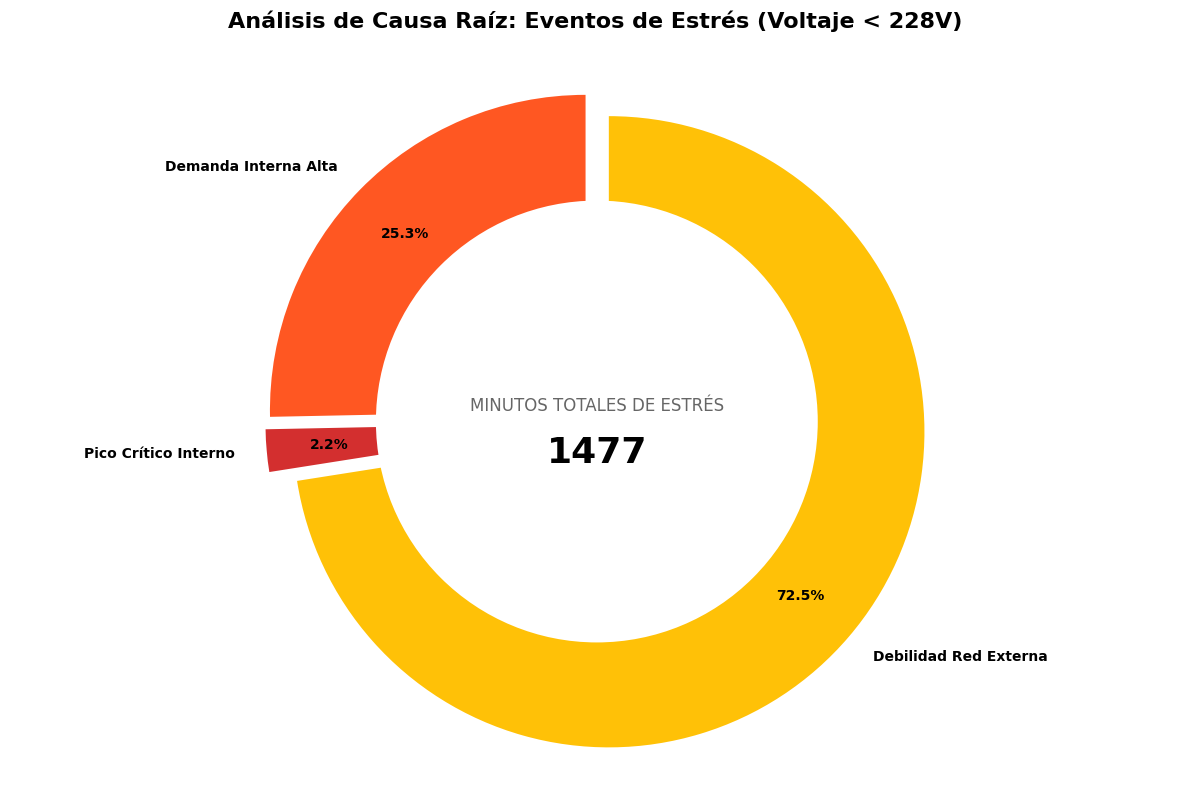

In [9]:
# ==============================================================================
# H4 VISUALIZACIÓN FINAL: ANÁLISIS DE CAUSA RAÍZ
# ==============================================================================
import matplotlib.pyplot as plt
import os

stress_df = H4_Validation_Report.filter("technical_responsibility_tag != 'Healthy'")
total_stress_events = stress_df.count()

stress_data = (
    stress_df
    .groupBy("technical_responsibility_tag")
    .count()
    .toPandas()
)

diccionario_esp = {
    "External/Grid Weakness (Standard Load Drop)": "Debilidad Red Externa",
    "Internal/High Demand (Above P95)":            "Demanda Interna Alta",
    "Internal/Critical Peak (Installation Stress)": "Pico Crítico Interno",
    "Mixed/Ambient Stress":                        "Estrés Mixto"
}
stress_data["technical_responsibility_tag"] = stress_data["technical_responsibility_tag"].map(diccionario_esp)

fig, ax = plt.subplots(figsize=(12, 8))

colors_dict = {
    "Debilidad Red Externa": "#FFC107",
    "Demanda Interna Alta":  "#FF5722",
    "Pico Crítico Interno":  "#D32F2F",
    "Estrés Mixto":          "#9E9E9E"
}
current_colors = [colors_dict.get(x, "#17a2b8") for x in stress_data["technical_responsibility_tag"]]

wedges, texts, autotexts = ax.pie(
    stress_data["count"],
    labels=stress_data["technical_responsibility_tag"],
    autopct="%1.1f%%",
    startangle=90,
    colors=current_colors,
    explode=[0.05] * len(stress_data),
    pctdistance=0.80,
    textprops={"fontsize": 10, "fontweight": "bold"}
)
plt.setp(autotexts, size=10, color="black")

centre_circle = plt.Circle((0, 0), 0.70, fc="white")
ax.add_artist(centre_circle)

ax.text(0, 0.05,  "MINUTOS TOTALES DE ESTRÉS", ha="center", va="center", fontsize=12, color="#666666")
ax.text(0, -0.10, f"{total_stress_events}",    ha="center", va="center", fontsize=26, fontweight="bold")

plt.title("Análisis de Causa Raíz: Eventos de Estrés (Voltaje < 228V)",
          fontsize=16, fontweight="bold", pad=25)
ax.axis("equal")
plt.tight_layout()

plot_path = os.path.join(PROJECT_ROOT, "docs", "figures", "H4_root_cause_analysis.png")
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"✅ GRÁFICO EXPORTADO: {plot_path}")
plt.show()

✅ GRÁFICO DE CORRELACIÓN EXPORTADO: /home/aitor/Documentos/Residential-Power-Audit-Spark-Pipeline/docs/figures/H4_correlation_stress.png


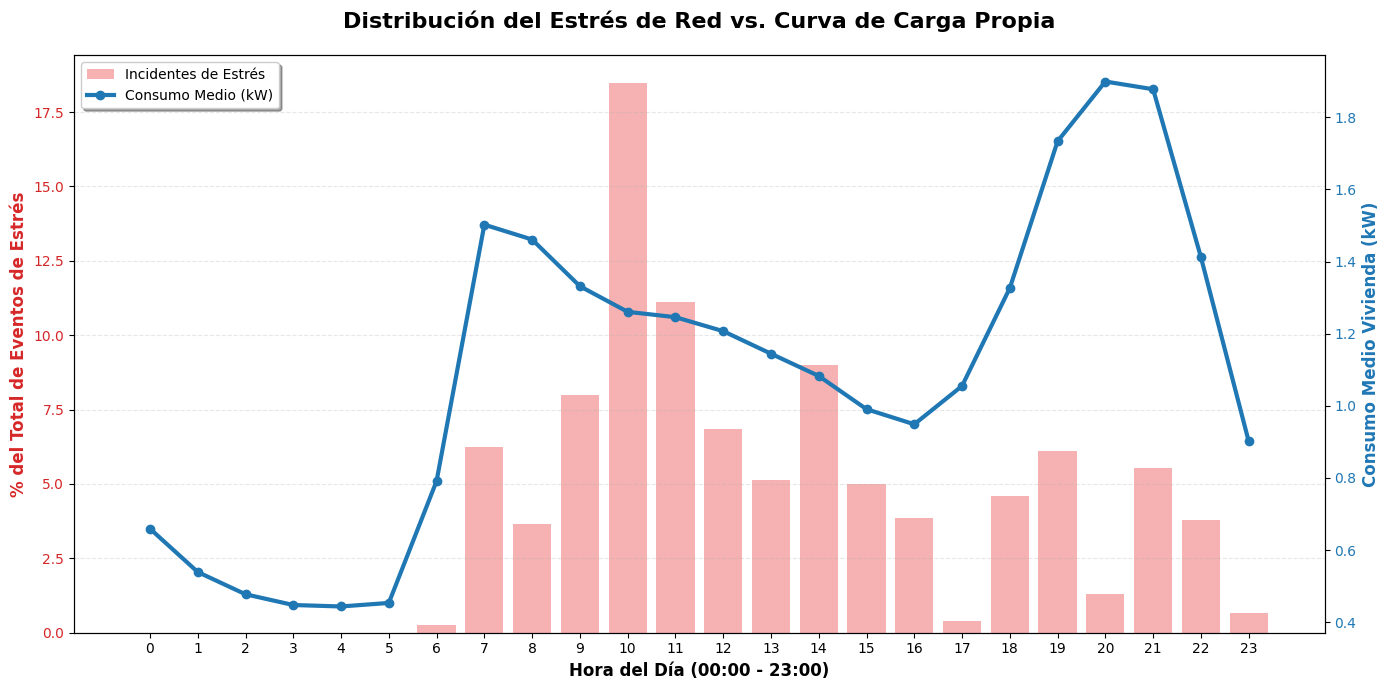

In [10]:
# ==============================================================================
# H4 CORRELATION ANALYSIS: GRID STRESS vs. HOUSEHOLD CONSUMPTION
# ==============================================================================
import matplotlib.pyplot as plt
import os
from pyspark.sql.functions import hour, col, avg, sum as _sum

hourly_stats = H4_Validation_Report.groupBy(hour("Full_Timestamp").alias("hour"))     .agg(
        _sum(col("is_stress_zone")).alias("stress_ratio"),
        avg(col("power_kw")).alias("avg_consumption_kw")
    )     .orderBy("hour")     .toPandas()

total_stress_minutes = hourly_stats["stress_ratio"].sum()
hourly_stats["stress_score"] = (hourly_stats["stress_ratio"] / total_stress_minutes) * 100

fig, ax1 = plt.subplots(figsize=(14, 7))

color_bars = "lightcoral"
ax1.set_xlabel("Hora del Día (00:00 - 23:00)", fontsize=12, fontweight="bold")
ax1.set_ylabel("% del Total de Eventos de Estrés", color="tab:red", fontsize=12, fontweight="bold")
ax1.bar(hourly_stats["hour"], hourly_stats["stress_score"],
        color=color_bars, alpha=0.6, label="Incidentes de Estrés")
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.set_xticks(range(0, 24))

ax2 = ax1.twinx()
color_line = "tab:blue"
ax2.set_ylabel("Consumo Medio Vivienda (kW)", color=color_line, fontsize=12, fontweight="bold")
ax2.plot(hourly_stats["hour"], hourly_stats["avg_consumption_kw"],
         color=color_line, marker="o", linewidth=3, label="Consumo Medio (kW)")
ax2.tick_params(axis="y", labelcolor=color_line)

plt.title("Distribución del Estrés de Red vs. Curva de Carga Propia",
          fontsize=16, fontweight="bold", pad=20)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

lines, labels   = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper left", frameon=True, shadow=True)

plt.tight_layout()

plot_path = os.path.join(PROJECT_ROOT, "docs", "figures", "H4_correlation_stress.png")
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"✅ GRÁFICO DE CORRELACIÓN EXPORTADO: {plot_path}")
plt.show()

---
## 4. Conclusiones — H4

<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

### ⚠️ HIPÓTESIS H4 — PARCIALMENTE VALIDADA

H4 queda **refutada** en cuanto a la responsabilidad de la instalación interna, pero **validada** en cuanto a la existencia de un riesgo real de fatiga electrónica por factores externos.

**Veredicto de infraestructura interna:** Sobresaliente. La instalación soporta picos de 11,1 kW manteniendo 229,7V — descartando bornes flojos o secciones de cable insuficientes.

**Debilidad de la red externa:** El 72,5% de los 1.477 minutos de estrés ocurren con carga interna baja — apuntando a saturación del transformador externo durante la actividad comercial matutina.

**Acciones estratégicas:**

| Nivel | Acción | Justificación técnica |
|-------|--------|----------------------|
| **Operativo** | Evitar cargas elevadas entre las 09:00–12:00 | No sumar demanda interna a una red externa ya debilitada |
| **Protección** | Instalar SAI de doble conversión para electrónica crítica | Aislar fuentes SMPS de la inestabilidad matutina |
| **Administrativo** | Reclamación formal a la distribuidora | 2,075M registros como evidencia documental bajo el RD 1955/2000 |
</div>